In [3]:
import json, re, collections, statistics
import matplotlib.pyplot as plt

ACCENT = ['#00b4d8','#7c3aed','#f59e0b','#10b981','#ef4444','#ec4899',
          '#06b6d4','#84cc16','#f97316','#a855f7','#14b8a6','#e11d48']

plt.rcParams.update({
    'axes.facecolor'  : '#0f1829',
    'figure.facecolor': '#0f1829',
    'axes.labelcolor' : '#94a3b8',
    'xtick.color'     : '#94a3b8',
    'ytick.color'     : '#94a3b8',
    'axes.edgecolor'  : '#1e293b',
    'grid.color'      : '#1e293b',
    'text.color'      : '#e2e8f0'
})

INPUT_FILE  = 'qiime2_filtred.jsonl'
OUTPUT_FILE = 'qiime2_VF.jsonl'


raw = []
with open(INPUT_FILE, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                raw.append(json.loads(line))
            except:
                pass

def get_category(r):
    if 'category' in r:
        return r['category']
    return r.get('metadata', {}).get('category', 'unknown')

print(f'Loaded          : {len(raw):,} records')
print(f'Fields          : {list(raw[0].keys()) if raw else "empty"}')
print(f'Sample category : {get_category(raw[0]) if raw else "N/A"}')

Loaded          : 268 records
Fields          : ['instruction', 'input', 'output', 'metadata']
Sample category : workflow_design


=== CATEGORY DISTRIBUTION (before filter) ===
  technical_troubleshooting                    :   183  (68.3%)
  workflow_design                              :    61  (22.8%)
  factual_conceptual                           :    24  (9.0%)


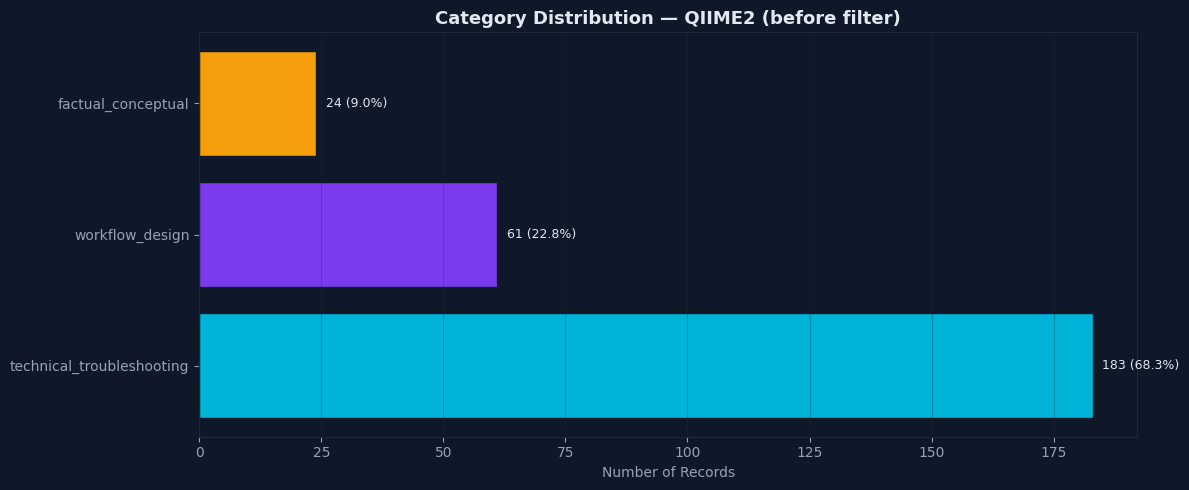

In [ ]:
# Category distribution before filter

cat_counts = collections.Counter(get_category(r) for r in raw)

print('=== CATEGORY DISTRIBUTION (before filter) ===')
for cat, cnt in cat_counts.most_common():
    print(f'  {cat:45s}: {cnt:5d}  ({cnt/len(raw)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 5))
labels, vals = zip(*cat_counts.most_common())
bars = ax.barh(labels, vals, color=ACCENT[:len(labels)], edgecolor='#0f1829')
ax.set_title('Category Distribution — QIIME2 (before filter)',
             color='#e2e8f0', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Records')
for bar, val in zip(bars, vals):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f'{val} ({val/len(raw)*100:.1f}%)', va='center', fontsize=9)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Stats before filter

ans_len  = [len(r.get('output','').split())      for r in raw]
inst_len = [len(r.get('instruction','').split()) for r in raw]

print('=== ANSWER LENGTH ===')
print(f'  Mean   : {statistics.mean(ans_len):.1f} words')
print(f'  Median : {statistics.median(ans_len):.1f} words')
print(f'  Min    : {min(ans_len)}')
print(f'  Max    : {max(ans_len)}')
print('\n=== INSTRUCTION LENGTH ===')
print(f'  Mean   : {statistics.mean(inst_len):.1f} words')
print(f'  Median : {statistics.median(inst_len):.1f} words')

=== ANSWER LENGTH ===
  Mean   : 92.4 words
  Median : 86.0 words
  Min    : 5
  Max    : 316

=== INSTRUCTION LENGTH ===
  Mean   : 24.5 words
  Median : 23.0 words


In [6]:
# Metagenomic / QIIME2 domain filter

KEEP_KEYWORDS = [
    'qiime','qiime2','qiime 2','amplicon','16s','18s','its','otu','asv','dada2',
    'deblur','feature','taxonomy','silva','greengenes','rdp','classifier',
    'microbiome','microbiota','diversity','alpha','beta','unifrac','bray',
    'phylogenetic','phylogeny','mafft','fasttree','emperor','pcoa',
    'rarefaction','sampling depth','manifest','demultiplex','barcode',
    'primer','paired-end','single-end','cutadapt','trimming','quality',
    'fastq','visualization','artifact','plugin','conda','biom','metadata',
    'feature-table','feature-classifier','alignment','tree','rooted',
    'unrooted','shotgun','metagenom','abundan','differential'
]

REMOVE_KEYWORDS = [
    'rna-seq','rnaseq','transcriptom','mrna','expression level',
    'chip-seq','atac-seq','gwas','somatic','variant calling',
    'snp calling','single cell','scrna','protein structure',
    'proteomics','metabolomics'
]

def is_relevant(r):
    text = (
        r.get('instruction','') + ' ' +
        r.get('input','')       + ' ' +
        r.get('output','')
    ).lower()
    return (any(kw in text for kw in KEEP_KEYWORDS) and
            not any(kw in text for kw in REMOVE_KEYWORDS))

relevant = [r for r in raw if is_relevant(r)]
print(f'Before filter : {len(raw):,}')
print(f'After filter  : {len(relevant):,}  ({len(relevant)/len(raw)*100:.1f}%)')
print(f'Removed       : {len(raw)-len(relevant):,}  ({(len(raw)-len(relevant))/len(raw)*100:.1f}%)')

Before filter : 268
After filter  : 264  (98.5%)
Removed       : 4  (1.5%)


In [7]:
# Clean — remove metadata, keep instruction/input/output/category

def clean_record(r):
    instruction = r.get('instruction','').strip()
    output      = r.get('output','').strip()
    if not instruction or not output: return None
    if len(output.split()) < 10:      return None
    if len(instruction.split()) < 5:  return None
    return {
        'instruction': instruction,
        'input'      : r.get('input','').strip(),
        'output'     : output,
        'category'   : get_category(r)
    }

seen, cleaned = set(), []
for r in relevant:
    c = clean_record(r)
    if not c: continue
    key = re.sub(r'\W+','', c['instruction'].lower())[:80]
    if key not in seen:
        seen.add(key)
        cleaned.append(c)

print(f'After cleaning + dedup : {len(cleaned):,}')
print(f'\nSample record:')
sample = cleaned[0].copy()
sample['output'] = sample['output'][:100] + '...'
print(json.dumps(sample, indent=2))

After cleaning + dedup : 262

Sample record:
{
  "instruction": "Provide guidance on where to obtain pre\u2011formatted databases for ready\u2011to\u2011run 18S rRNA data analysis.",
  "input": "",
  "output": "Use the pre\u2011formatted SILVA database, which contains all SSU (small subunit) rRNA gene sequences, in...",
  "category": "workflow_design"
}


=== CATEGORY DISTRIBUTION (after filter) ===
  technical_troubleshooting                    :   178  (67.9%)
  workflow_design                              :    60  (22.9%)
  factual_conceptual                           :    24  (9.2%)


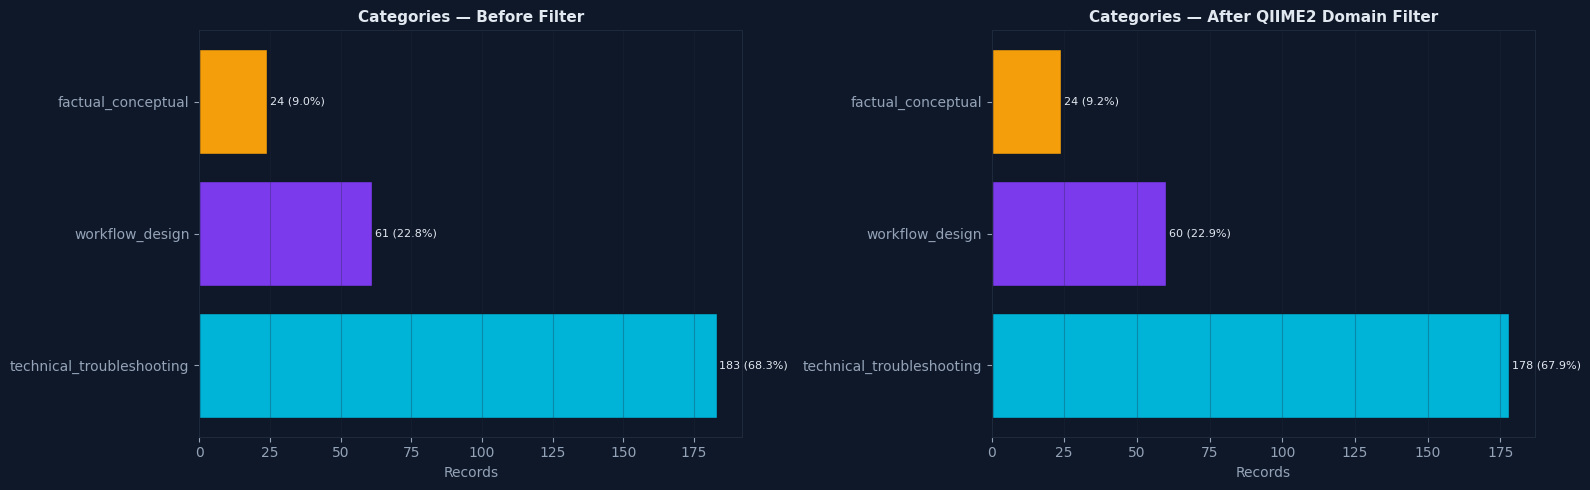

In [ ]:
# Category distribution after filter — comparison

cat_after = collections.Counter(r['category'] for r in cleaned)

print('=== CATEGORY DISTRIBUTION (after filter) ===')
for cat, cnt in cat_after.most_common():
    print(f'  {cat:45s}: {cnt:5d}  ({cnt/len(cleaned)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, counts, title in zip(
    axes,
    [cat_counts, cat_after],
    ['Before Filter', 'After QIIME2 Domain Filter']
):
    if not counts: continue
    labels, vals = zip(*counts.most_common())
    bars = ax.barh(labels, vals, color=ACCENT[:len(labels)], edgecolor='#0f1829')
    ax.set_title(f'Categories — {title}', color='#e2e8f0',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Records')
    total = sum(counts.values())
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                f'{val} ({val/total*100:.1f}%)', va='center', fontsize=8)
    ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Final summary + export

ans_final  = [len(r['output'].split())      for r in cleaned]
inst_final = [len(r['instruction'].split()) for r in cleaned]

print('=== FINAL DATASET SUMMARY ===')
print(f'  Total records          : {len(cleaned):,}')
print(f'  Avg instruction length : {statistics.mean(inst_final):.1f} words')
print(f'  Avg output length      : {statistics.mean(ans_final):.1f} words')
print(f'  Median output length   : {statistics.median(ans_final):.1f} words')
print(f'  Records with input     : {sum(1 for r in cleaned if r["input"]):,}')
print(f'  Records without input  : {sum(1 for r in cleaned if not r["input"]):,}')

with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
    for r in cleaned:
        f.write(json.dumps(r, ensure_ascii=False) + '\n')

print(f'\nRaw                    : {len(raw):,}')
print(f'After domain filter    : {len(relevant):,}')
print(f'After cleaning + dedup : {len(cleaned):,}')
print(f'Saved: {OUTPUT_FILE}')

=== FINAL DATASET SUMMARY ===
  Total records          : 262
  Avg instruction length : 24.6 words
  Avg output length      : 92.8 words
  Median output length   : 86.0 words
  Records with input     : 249
  Records without input  : 13

Raw                    : 268
After domain filter    : 264
After cleaning + dedup : 262
Saved: qiime2_VF.jsonl
